In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb

In [3]:
loanfile=pd.read_csv("Loan Prediction Dataset.csv")

In [4]:
loanfile.shape

(614, 13)

In [5]:
loanfile.isnull().sum()

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

In [11]:
loanfile["Gender"].fillna(loanfile["Gender"].mode()[0],inplace=True)
loanfile["Married"].fillna(loanfile["Married"].mode()[0],inplace=True)
loanfile["Dependents"].fillna(loanfile["Dependents"].mode()[0],inplace=True)
loanfile["Self_Employed"].fillna(loanfile["Self_Employed"].mode()[0],inplace=True)
loanfile["Credit_History"] = loanfile["Credit_History"].fillna(loanfile["Credit_History"].mode()[0])

In [9]:
loanfile.isnull().sum()

Loan_ID               0
Gender                0
Married               0
Dependents            0
Education             0
Self_Employed         0
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History        0
Property_Area         0
Loan_Status           0
dtype: int64

In [13]:
loanfile["LoanAmount"] = loanfile["LoanAmount"].fillna(loanfile["LoanAmount"].median())
loanfile["Loan_Amount_Term"] = loanfile["Loan_Amount_Term"].fillna(loanfile["Loan_Amount_Term"].median())

In [14]:
loanfile.isnull().sum()

Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

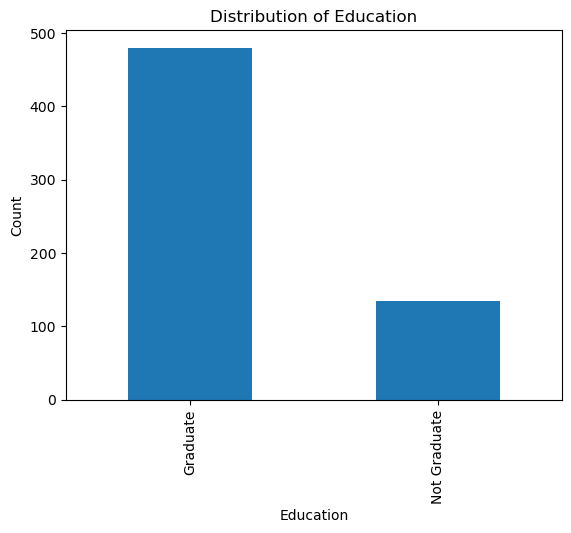

In [18]:
loanfile["Education"].value_counts().plot(
    kind="bar"
)

plt.title("Distribution of Education")
plt.xlabel("Education")
plt.ylabel("Count")
plt.show()

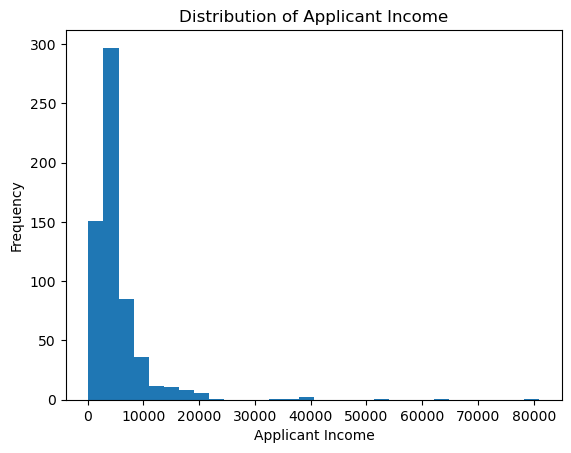

In [19]:
plt.hist(
    loanfile["ApplicantIncome"],
    bins=30
)

plt.title("Distribution of Applicant Income")
plt.xlabel("Applicant Income")
plt.ylabel("Frequency")

plt.show()

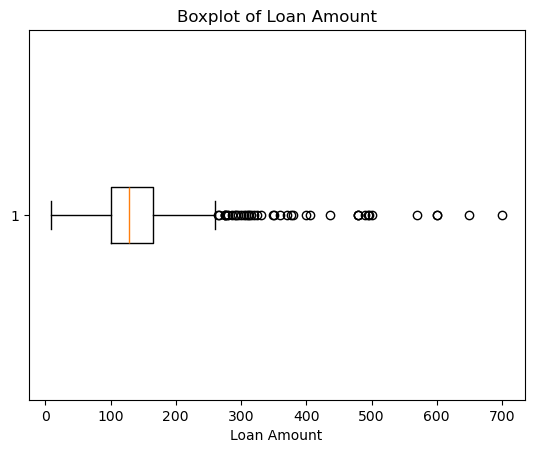

In [20]:
plt.boxplot(
    loanfile["LoanAmount"].dropna(),
    vert=False
)

plt.title("Boxplot of Loan Amount")
plt.xlabel("Loan Amount")

plt.show()

In [21]:
loanfile.drop(columns=['Loan_ID'],inplace=True)

In [22]:
loanfile_binaryencoded=pd.get_dummies(loanfile,drop_first=True)

In [23]:
loanfile_binaryencoded.dtypes

ApplicantIncome              int64
CoapplicantIncome          float64
LoanAmount                 float64
Loan_Amount_Term           float64
Credit_History             float64
Gender_Male                   bool
Married_Yes                   bool
Dependents_1                  bool
Dependents_2                  bool
Dependents_3+                 bool
Education_Not Graduate        bool
Self_Employed_Yes             bool
Property_Area_Semiurban       bool
Property_Area_Urban           bool
Loan_Status_Y                 bool
dtype: object

In [24]:
loanfile_binaryencoded.columns

Index(['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Gender_Male', 'Married_Yes',
       'Dependents_1', 'Dependents_2', 'Dependents_3+',
       'Education_Not Graduate', 'Self_Employed_Yes',
       'Property_Area_Semiurban', 'Property_Area_Urban', 'Loan_Status_Y'],
      dtype='object')

In [25]:
y = loanfile_binaryencoded['Loan_Status_Y']

In [26]:
x = loanfile_binaryencoded.drop(columns='Loan_Status_Y')

In [27]:
from sklearn.model_selection import train_test_split

In [28]:
from sklearn.linear_model import LogisticRegression

In [30]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [31]:
x_train.shape

(491, 14)

In [32]:
model = LogisticRegression(max_iter=1000)

In [34]:
model.fit(x_train, y_train)

D:\Users\hp\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000)

In [35]:
from sklearn.preprocessing import StandardScaler

In [36]:
scaler = StandardScaler()

In [37]:
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [39]:
model = LogisticRegression(max_iter=1000)
model.fit(x_train_scaled, y_train)

LogisticRegression(max_iter=1000)

In [40]:
predictions = model.predict(x_test_scaled)

In [41]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [42]:
accuracy = accuracy_score(y_test, predictions)
print(f"Model Accuracy: {accuracy * 100:.2f}%\n")

Model Accuracy: 78.86%



In [43]:
print("Confusion Matrix:")
print(confusion_matrix(y_test, predictions))

Confusion Matrix:
[[18 25]
 [ 1 79]]


In [44]:
print("\nClassification Report:")
print(classification_report(y_test, predictions))


Classification Report:
              precision    recall  f1-score   support

       False       0.95      0.42      0.58        43
        True       0.76      0.99      0.86        80

    accuracy                           0.79       123
   macro avg       0.85      0.70      0.72       123
weighted avg       0.83      0.79      0.76       123



Model Evaluation & Business Conclusion

The Logistic Regression model achieved an accuracy of 78.86% after applying feature scaling. The model performs well in identifying applicants who are likely to repay their loans, making it useful for automated loan screening. However, some high-risk applicants were incorrectly approved, mainly influenced by Credit_History. In future improvements, the model can be made slightly more conservative to reduce financial risk while maintaining efficient loan evaluation.